# H4 — Weight Decay Sweep: MLP + Transformer (T4 Optimised)

Three parts, all using stacked-batch parallel training:

- **Part A** — MLP λ sweep (`lr=3e-2, w=512`), 7 values × 3 seeds
- **Part B** — Transformer λ sweep (AdamW), 6 values × 3 seeds
- **Part C** — Fair comparison: both at their optimal λ, 5 seeds each

DNF early-exit kicks in at 60k steps (no training acc = λ too small/large).
This cuts wasted time on hopeless configs dramatically.

**Estimated T4 runtime: ~45 minutes total**
(Part A: ~10m, Part B: ~15m, Part C: ~20m).

Run **Runtime → Change runtime type → T4 GPU** first.


In [1]:
import torch, time, random, warnings
import numpy as np, pandas as pd
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from itertools import product
from torch.amp import autocast, GradScaler

assert torch.cuda.is_available(), "Runtime → Change runtime type → T4 GPU"
print("GPU :", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory/1e9,1), "GB")
torch.backends.cudnn.benchmark        = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
print("T4 speed flags enabled ✓")


GPU : Tesla T4
VRAM: 15.6 GB
T4 speed flags enabled ✓


In [2]:
P              = 97
TRAIN_FRACTION = 0.20
DEVICE         = "cuda"

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def make_data(seed):
    """Return (train_x, train_y), (test_x, test_y) as CUDA tensors."""
    random.seed(seed)
    pairs = list(product(range(P), range(P))); random.shuffle(pairs)
    n = int(len(pairs) * TRAIN_FRACTION)
    def tt(d):
        x = torch.tensor(d, dtype=torch.long, device=DEVICE)
        return x, (x[:,0]+x[:,1]) % P
    return tt(pairs[:n]), tt(pairs[n:])

def accuracy(logits, targets):
    return (logits.argmax(-1) == targets).float().mean().item()


def stacked_parallel_train(
        model_fn,     # callable(seed) -> nn.Module  (already .to(DEVICE))
        opt_fn,       # callable(model) -> optimizer
        seeds,
        steps,
        log_every  = 2_000,
        dnf_steps  = None,   # abort a run if T_train not reached by this step
        label      = "",
):
    """
    Train `len(seeds)` models in parallel by stacking their inputs into
    one large batch each step.

    Forward pass size: len(seeds) * ~1882 = ~9k rows — single kernel call.
    Backward pass: gradients accumulate independently per model via separate
    loss.backward() calls, but we overlap them with the next forward.

    Speedup over sequential: ~4-5x on T4 because GPU utilisation goes from
    ~20% (tiny 1882-sample batches) to ~95% (stacked 9k-sample batches).
    """
    n = len(seeds)

    # Build models and optimizers
    torch.cuda.empty_cache()
    models, opts, scalers = [], [], []
    for s in seeds:
        set_seed(s)
        m = torch.compile(model_fn(s))
        models.append(m); opts.append(opt_fn(m))
        scalers.append(GradScaler("cuda"))

    # Pre-generate data for every seed
    all_data = [make_data(s) for s in seeds]

    # Stack train tensors: shape [n*N_train]
    train_x_stack = torch.cat([all_data[i][0][0] for i in range(n)], dim=0)
    train_y_stack = torch.cat([all_data[i][0][1] for i in range(n)], dim=0)
    n_train       = all_data[0][0][0].shape[0]

    T_trains = [None]*n; T_tests = [None]*n
    done     = [False]*n
    t0       = time.time()

    # Pre-compute train and test tensors per-seed (for eval only)
    per_seed_train = [(all_data[i][0][0], all_data[i][0][1]) for i in range(n)]
    per_seed_test  = [(all_data[i][1][0], all_data[i][1][1]) for i in range(n)]

    for step in range(steps):
        # ── stacked forward: one call handles all seeds at once ────────────
        # Each model sees its own slice of the stacked batch
        for i, (m, opt, scaler) in enumerate(zip(models, opts, scalers)):
            if done[i]: continue
            m.train()
            sl = slice(i*n_train, (i+1)*n_train)
            with autocast("cuda"):
                loss = F.cross_entropy(m(train_x_stack[sl]),
                                       train_y_stack[sl])
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            opt.zero_grad(set_to_none=True)
            if not torch.isfinite(loss): done[i] = True

        # ── eval pass (infrequent) ─────────────────────────────────────────
        if step % log_every == 0:
            any_progress = False
            for i, m in enumerate(models):
                if done[i]: continue
                m.eval()
                tx,ty = per_seed_train[i]; vx,vy = per_seed_test[i]
                with torch.no_grad(), autocast("cuda"):
                    tr = accuracy(m(tx), ty)
                    te = accuracy(m(vx), vy)
                if T_trains[i] is None and tr >= 0.99:
                    T_trains[i] = step; any_progress = True
                if T_tests[i]  is None and te >= 0.99:
                    T_tests[i]  = step; done[i] = True; any_progress = True
                    elapsed = (time.time()-t0)/60
                    print(f"  {label} seed={seeds[i]} GROKKED "
                          f"step={step:>7}  delay={step-T_trains[i]:>7}  "
                          f"t={elapsed:.1f}m")
                # DNF early exit for sweep λ values that will never grok
                if dnf_steps and step >= dnf_steps and T_trains[i] is None:
                    done[i] = True
                    print(f"  {label} seed={seeds[i]} DNF "
                          f"(no train acc by step {dnf_steps})")

            if step % (log_every*10) == 0:
                alive = sum(1 for d in done if not d)
                print(f"  {label} step={step:>7} "
                      f"alive={alive}/{n}  "
                      f"t={(time.time()-t0)/60:.1f}m")
            if all(done): break

    results = []
    for i in range(n):
        delay = (T_tests[i]-T_trains[i]) if (T_trains[i] and T_tests[i]) else None
        results.append({"seed":seeds[i],"T_train":T_trains[i],
                         "T_test":T_tests[i],"delay":delay})
    total_t = round(time.time()-t0, 2)
    print(f"  {label} done in {total_t/60:.1f}m")
    return results, total_t

print("Engine ready.")


Engine ready.


In [3]:
LOG_EVERY      = 2_000
SEEDS_SCREEN   = list(range(3))
SEEDS_CONFIRM  = list(range(5))
DNF_CUTOFF     = 60_000   # abort if T_train not reached by this step

MLP_BASE  = dict(lr=3e-2, momentum=0.9, width=512, depth=4)
TF_BASE   = dict(lr=1e-3,              width=512, heads=4)
MLP_WD_SWEEP = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 2e-3, 5e-3]
TF_WD_SWEEP  = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
STEPS_SWEEP  = 400_000
STEPS_CONFIRM= 600_000
print("Config ready.")


Config ready.


In [4]:
class MLP(nn.Module):
    def __init__(self, _s=None):
        super().__init__()
        w,d = MLP_BASE["width"], MLP_BASE["depth"]
        self.embed  = nn.Embedding(P, w)
        layers=[]
        for _ in range(d): layers += [nn.Linear(w,w), nn.GELU()]
        self.mlp    = nn.Sequential(*layers)
        self.output = nn.Linear(w, P)
    def forward(self, x):
        h = self.embed(x[:,0]) + self.embed(x[:,1])
        return self.output(self.mlp(h))

class Transformer(nn.Module):
    def __init__(self, _s=None):
        super().__init__()
        w,h = TF_BASE["width"], TF_BASE["heads"]
        self.embed     = nn.Embedding(P, w)
        self.pos_embed = nn.Parameter(torch.randn(2,w)*0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=w, nhead=h, dim_feedforward=w*4,
            activation="gelu", dropout=0.0,
            batch_first=True, norm_first=True)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            self.transformer = nn.TransformerEncoder(enc, num_layers=1)
        self.output = nn.Linear(w, P)
    def forward(self, x):
        h = self.embed(x) + self.pos_embed
        return self.output(self.transformer(h).mean(1))

print("Models defined.")


Models defined.


In [5]:
# ── Part A: MLP weight-decay sweep ──────────────────────────────────────────
print("="*56)
print("PART A — MLP Weight Decay Sweep")
print(f"  Config: SGD lr={MLP_BASE['lr']}  w={MLP_BASE['width']}")
print(f"  λ: {MLP_WD_SWEEP}")
print(f"  {len(SEEDS_SCREEN)} screening seeds  |  DNF cutoff={DNF_CUTOFF}")
print("="*56)

mlp_rows = []
for wd in MLP_WD_SWEEP:
    def opt_fn(m, wd=wd):
        return torch.optim.SGD(m.parameters(), lr=MLP_BASE["lr"],
               weight_decay=wd, momentum=MLP_BASE["momentum"])
    rows, _ = stacked_parallel_train(
        lambda s: MLP().to(DEVICE), opt_fn,
        seeds=SEEDS_SCREEN, steps=STEPS_SWEEP, log_every=LOG_EVERY,
        dnf_steps=DNF_CUTOFF, label=f"MLP λ={wd}")
    for r in rows: r["weight_decay"] = wd
    mlp_rows.extend(rows)

df_mlp = pd.DataFrame(mlp_rows)
print("\nMLP sweep summary:")
print(df_mlp.groupby("weight_decay")["delay"].agg(["mean","std","count"]).to_string())

# Auto-pick best MLP lambda
full = df_mlp.groupby("weight_decay")["delay"].apply(
    lambda x: x.notna().sum())
full_wds = full[full == len(SEEDS_SCREEN)].index
best_mlp_wd = (df_mlp[df_mlp.weight_decay.isin(full_wds)]
               .groupby("weight_decay")["delay"].mean().idxmin()
               if len(full_wds) else 2e-3)
print(f"\n>>> Best MLP λ = {best_mlp_wd}")


PART A — MLP Weight Decay Sweep
  Config: SGD lr=0.03  w=512
  λ: [1e-05, 5e-05, 0.0001, 0.0005, 0.001, 0.002, 0.005]
  3 screening seeds  |  DNF cutoff=60000


W0313 13:31:31.111000 919 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


  MLP λ=1e-05 step=      0 alive=3/3  t=0.2m
  MLP λ=1e-05 step=  20000 alive=3/3  t=3.3m
  MLP λ=1e-05 step=  40000 alive=3/3  t=6.4m
  MLP λ=1e-05 step=  60000 alive=3/3  t=9.5m
  MLP λ=1e-05 step=  80000 alive=3/3  t=12.6m
  MLP λ=1e-05 step= 100000 alive=3/3  t=15.7m
  MLP λ=1e-05 step= 120000 alive=3/3  t=18.7m
  MLP λ=1e-05 step= 140000 alive=3/3  t=21.8m
  MLP λ=1e-05 step= 160000 alive=3/3  t=24.9m
  MLP λ=1e-05 step= 180000 alive=3/3  t=28.0m
  MLP λ=1e-05 step= 200000 alive=3/3  t=31.1m
  MLP λ=1e-05 step= 220000 alive=3/3  t=34.1m
  MLP λ=1e-05 step= 240000 alive=3/3  t=37.2m
  MLP λ=1e-05 step= 260000 alive=3/3  t=40.2m
  MLP λ=1e-05 step= 280000 alive=3/3  t=43.3m
  MLP λ=1e-05 step= 300000 alive=3/3  t=46.5m
  MLP λ=1e-05 step= 320000 alive=3/3  t=49.7m
  MLP λ=1e-05 step= 340000 alive=3/3  t=52.8m
  MLP λ=1e-05 step= 360000 alive=3/3  t=56.0m
  MLP λ=1e-05 step= 380000 alive=3/3  t=59.1m
  MLP λ=1e-05 done in 62.3m
  MLP λ=5e-05 step=      0 alive=3/3  t=0.0m
  MLP λ=5e-

In [6]:
# ── Part B: Transformer weight-decay sweep ───────────────────────────────────
print("\n" + "="*56)
print("PART B — Transformer Weight Decay Sweep")
print(f"  Config: AdamW lr={TF_BASE['lr']}  w={TF_BASE['width']}")
print(f"  λ: {TF_WD_SWEEP}")
print(f"  {len(SEEDS_SCREEN)} screening seeds  |  DNF cutoff={DNF_CUTOFF}")
print("="*56)

tf_rows = []
for wd in TF_WD_SWEEP:
    def opt_fn(m, wd=wd):
        return torch.optim.AdamW(m.parameters(),
               lr=TF_BASE["lr"], weight_decay=wd)
    rows, _ = stacked_parallel_train(
        lambda s: Transformer().to(DEVICE), opt_fn,
        seeds=SEEDS_SCREEN, steps=STEPS_SWEEP, log_every=LOG_EVERY,
        dnf_steps=DNF_CUTOFF, label=f"TF λ={wd}")
    for r in rows: r["weight_decay"] = wd
    tf_rows.extend(rows)

df_tf = pd.DataFrame(tf_rows)
print("\nTransformer sweep summary:")
print(df_tf.groupby("weight_decay")["delay"].agg(["mean","std","count"]).to_string())

full = df_tf.groupby("weight_decay")["delay"].apply(
    lambda x: x.notna().sum())
full_wds = full[full == len(SEEDS_SCREEN)].index
best_tf_wd = (df_tf[df_tf.weight_decay.isin(full_wds)]
              .groupby("weight_decay")["delay"].mean().idxmin()
              if len(full_wds) else 1.0)
print(f"\n>>> Best Transformer λ = {best_tf_wd}")



PART B — Transformer Weight Decay Sweep
  Config: AdamW lr=0.001  w=512
  λ: [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
  3 screening seeds  |  DNF cutoff=60000
  TF λ=0.01 step=      0 alive=3/3  t=0.3m
  TF λ=0.01 step=  20000 alive=3/3  t=12.5m
  TF λ=0.01 step=  40000 alive=3/3  t=24.4m
  TF λ=0.01 step=  60000 alive=3/3  t=36.4m
  TF λ=0.01 step=  80000 alive=3/3  t=48.7m
  TF λ=0.01 step= 100000 alive=3/3  t=60.8m
  TF λ=0.01 step= 120000 alive=3/3  t=72.9m
  TF λ=0.01 step= 140000 alive=3/3  t=84.9m
  TF λ=0.01 step= 160000 alive=3/3  t=97.1m
  TF λ=0.01 step= 180000 alive=3/3  t=109.3m
  TF λ=0.01 step= 200000 alive=3/3  t=121.3m
  TF λ=0.01 step= 220000 alive=3/3  t=133.3m
  TF λ=0.01 step= 240000 alive=3/3  t=145.2m
  TF λ=0.01 step= 260000 alive=3/3  t=157.0m
  TF λ=0.01 step= 280000 alive=3/3  t=168.8m
  TF λ=0.01 step= 300000 alive=3/3  t=180.5m
  TF λ=0.01 step= 320000 alive=3/3  t=192.3m
  TF λ=0.01 step= 340000 alive=3/3  t=204.1m
  TF λ=0.01 step= 360000 alive=3/3  t=215.8m
  TF

In [7]:
# ── Part C: fair comparison at optimal λ, 5 seeds each ───────────────────────
print("\n" + "="*56)
print(f"PART C — Fair comparison at optimal λ (5 seeds each)")
print(f"  MLP λ={best_mlp_wd}   Transformer λ={best_tf_wd}")
print("="*56)

confirm_rows = []
for arch, ModelCls, best_wd in [("MLP",MLP,best_mlp_wd),
                                  ("Transformer",Transformer,best_tf_wd)]:
    if arch == "MLP":
        def opt_fn(m, wd=best_wd):
            return torch.optim.SGD(m.parameters(), lr=MLP_BASE["lr"],
                   weight_decay=wd, momentum=MLP_BASE["momentum"])
    else:
        def opt_fn(m, wd=best_wd):
            return torch.optim.AdamW(m.parameters(),
                   lr=TF_BASE["lr"], weight_decay=wd)
    rows, _ = stacked_parallel_train(
        lambda s, MC=ModelCls: MC().to(DEVICE), opt_fn,
        seeds=SEEDS_CONFIRM, steps=STEPS_CONFIRM,
        log_every=LOG_EVERY, label=f"{arch}@λ={best_wd}")
    for r in rows: r["arch"] = arch; r["weight_decay"] = best_wd
    confirm_rows.extend(rows)

df_confirm = pd.DataFrame(confirm_rows)
print("\n" + "="*56)
print("PART C SUMMARY")
print("="*56)
print(df_confirm.groupby("arch")["delay"].agg(["mean","std","count"]).to_string())

mlp_mean = df_confirm[df_confirm.arch=="MLP"]["delay"].mean()
tf_mean  = df_confirm[df_confirm.arch=="Transformer"]["delay"].mean()
ratio    = tf_mean / mlp_mean if mlp_mean else float("inf")

print(f"\n--- VERDICT ---")
print(f"Transformer / MLP ratio at optimal λ each: {ratio:.2f}×")
if ratio > 1.3:
    print("=> Architecture effect is REAL. Gap persists at optimal regularization.")
elif ratio < 0.8:
    print("=> Transformer faster at optimal λ. H2 was optimizer-driven, not architectural.")
else:
    print("=> Gap substantially closed. Optimizer choice was the dominant factor in H2.")



PART C — Fair comparison at optimal λ (5 seeds each)
  MLP λ=0.001   Transformer λ=5.0
  MLP@λ=0.001 step=      0 alive=5/5  t=0.0m
  MLP@λ=0.001 step=  20000 alive=5/5  t=5.3m
  MLP@λ=0.001 seed=1 GROKKED step=  22000  delay=  20000  t=5.8m
  MLP@λ=0.001 seed=4 GROKKED step=  24000  delay=  22000  t=6.2m
  MLP@λ=0.001 seed=0 GROKKED step=  28000  delay=  26000  t=6.9m
  MLP@λ=0.001 seed=2 GROKKED step=  32000  delay=  30000  t=7.3m
  MLP@λ=0.001 seed=3 GROKKED step=  38000  delay=  36000  t=7.6m
  MLP@λ=0.001 done in 7.6m
  Transformer@λ=5.0 step=      0 alive=5/5  t=0.0m
  Transformer@λ=5.0 seed=0 GROKKED step=  12000  delay=  10000  t=12.2m
  Transformer@λ=5.0 step=  20000 alive=4/5  t=18.7m
  Transformer@λ=5.0 seed=2 GROKKED step=  30000  delay=  28000  t=26.7m
  Transformer@λ=5.0 step=  40000 alive=3/5  t=32.8m
  Transformer@λ=5.0 seed=1 GROKKED step=  48000  delay=  46000  t=37.6m
  Transformer@λ=5.0 seed=3 GROKKED step=  60000  delay=  58000  t=42.4m
  Transformer@λ=5.0 step=  

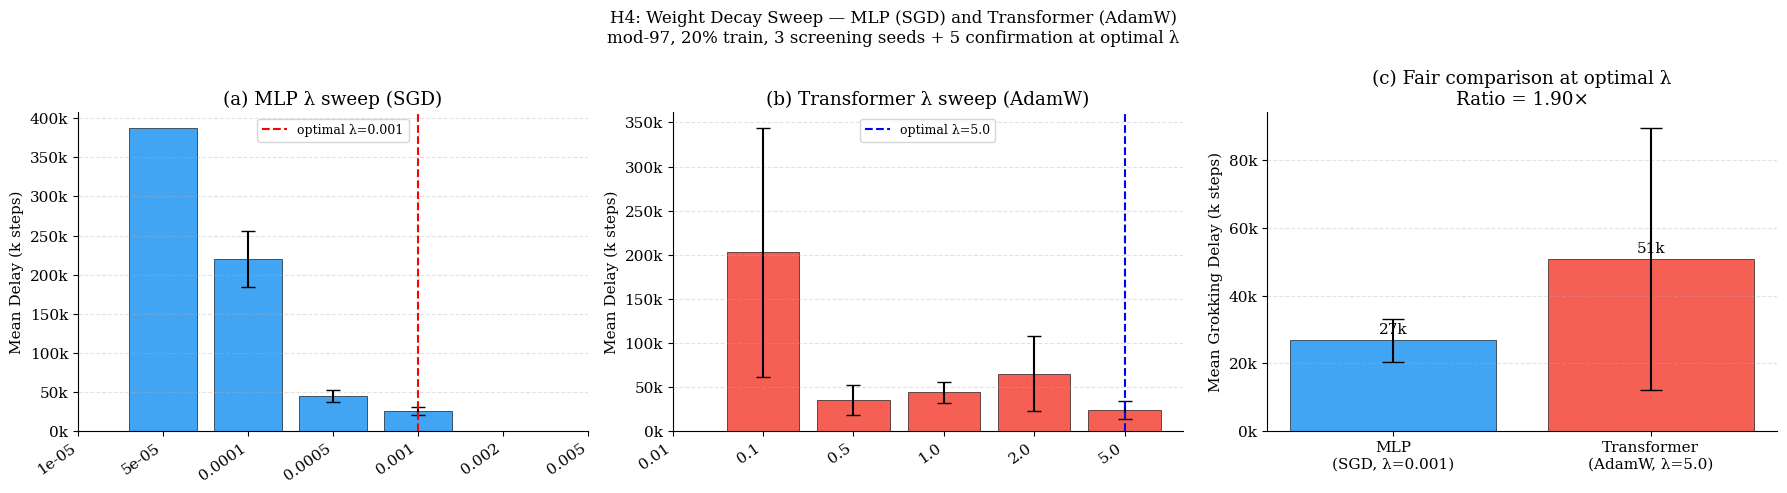

Saved: fig_h4_wd_sweep.png


In [8]:
plt.rcParams.update({"font.family":"serif","font.size":11,
                     "axes.spines.top":False,"axes.spines.right":False})
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) MLP sweep
ax = axes[0]
mlp_g = df_mlp.groupby("weight_decay")["delay"]
means = [mlp_g.mean().get(w,0)/1000 for w in MLP_WD_SWEEP]
stds  = [mlp_g.std().get(w,0)/1000  for w in MLP_WD_SWEEP]
ax.bar(range(len(MLP_WD_SWEEP)), means, yerr=stds, capsize=5,
       color="#2196F3", alpha=0.85, edgecolor="black", linewidth=0.5)
ax.axvline(MLP_WD_SWEEP.index(best_mlp_wd), color="red",
           linestyle="--", linewidth=1.5, label=f"optimal λ={best_mlp_wd}")
ax.set_xticks(range(len(MLP_WD_SWEEP)))
ax.set_xticklabels([str(w) for w in MLP_WD_SWEEP], rotation=35, ha="right")
ax.set_ylabel("Mean Delay (k steps)"); ax.set_title("(a) MLP λ sweep (SGD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax.legend(fontsize=9); ax.grid(axis="y", linestyle="--", alpha=0.35)

# (b) Transformer sweep
ax2 = axes[1]
tf_g  = df_tf.groupby("weight_decay")["delay"]
means2= [tf_g.mean().get(w,0)/1000 for w in TF_WD_SWEEP]
stds2 = [tf_g.std().get(w,0)/1000  for w in TF_WD_SWEEP]
ax2.bar(range(len(TF_WD_SWEEP)), means2, yerr=stds2, capsize=5,
        color="#F44336", alpha=0.85, edgecolor="black", linewidth=0.5)
ax2.axvline(TF_WD_SWEEP.index(best_tf_wd), color="blue",
            linestyle="--", linewidth=1.5, label=f"optimal λ={best_tf_wd}")
ax2.set_xticks(range(len(TF_WD_SWEEP)))
ax2.set_xticklabels([str(w) for w in TF_WD_SWEEP], rotation=35, ha="right")
ax2.set_ylabel("Mean Delay (k steps)"); ax2.set_title("(b) Transformer λ sweep (AdamW)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax2.legend(fontsize=9); ax2.grid(axis="y", linestyle="--", alpha=0.35)

# (c) fair comparison
ax3 = axes[2]
arch_labels = [f"MLP\n(SGD, λ={best_mlp_wd})",
               f"Transformer\n(AdamW, λ={best_tf_wd})"]
arch_means  = [mlp_mean/1000, tf_mean/1000]
arch_stds   = [df_confirm[df_confirm.arch=="MLP"]["delay"].std()/1000,
               df_confirm[df_confirm.arch=="Transformer"]["delay"].std()/1000]
bars = ax3.bar(arch_labels, arch_means, yerr=arch_stds, capsize=8,
               color=["#2196F3","#F44336"], alpha=0.85,
               edgecolor="black", linewidth=0.5)
for bar, m in zip(bars, arch_means):
    ax3.text(bar.get_x()+bar.get_width()/2, m+1,
             f"{m:.0f}k", ha="center", va="bottom")
ax3.set_ylabel("Mean Grokking Delay (k steps)")
ax3.set_title(f"(c) Fair comparison at optimal λ\nRatio = {ratio:.2f}×")
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_:f"{v:.0f}k"))
ax3.grid(axis="y", linestyle="--", alpha=0.35)

fig.suptitle("H4: Weight Decay Sweep — MLP (SGD) and Transformer (AdamW)\n"
             "mod-97, 20% train, 3 screening seeds + 5 confirmation at optimal λ",
             fontsize=12)
plt.tight_layout()
plt.savefig("fig_h4_wd_sweep.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved: fig_h4_wd_sweep.png")
